
# Desempenho Computacional e Fator de MÉRITO

Material de apoio ao TCC: Comparação e Otimização de Algoritmos de Monte
Carlo Aplicados ao Modelo de Ising (Diego R. Oliveira, UFPR).

Este notebook não roda nenhuma simulação nova. Ele combina dois números
já calculados nos notebooks anteriores, o tempo de execução de cada
rodada e o tempo de autocorrelação integrado, para produzir o Fator de
MÉRITO de cada algoritmo, seguindo a Seção 4.8.1 do TCC.

O Fator de MÉRITO mede quantas amostras estatisticamente independentes um
algoritmo consegue produzir por segundo de processamento real. Um
algoritmo pode ser muito rápido por passo e ainda assim ser ineficiente,
se cada passo produzir pouca informação nova por causa de correlações
fortes entre medidas sucessivas. O Fator de MÉRITO capta as duas coisas
ao mesmo tempo, velocidade bruta e qualidade estatística da amostragem,
em um único número comparável entre os três algoritmos.


In [1]:

import os
from google.colab import drive

drive.mount('/content/drive')

assert os.path.ismount('/content/drive'), (
    "ERRO. Google Drive nao esta montado de verdade. "
    "Nao prossiga ate resolver isso."
)
print("Drive confirmado como montado corretamente.")


Mounted at /content/drive
Drive confirmado como montado corretamente.


In [2]:

!git clone https://github.com/diegorafael1010/ising-monte-carlo.git


Cloning into 'ising-monte-carlo'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 38 (delta 17), reused 21 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 60.73 KiB | 840.00 KiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:

import glob
import re
import json

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/content/ising-monte-carlo')
from ising_utils import temperatura_critica_onsager

PASTA_DADOS = '/content/drive/MyDrive/0_TCC_Diego/dados'



## Colocando tau e tempo por passo na mesma unidade

Para Metropolis e Swendsen-Wang, um passo do algoritmo já equivale a um
MCS por sítio, então o tempo por passo salvo durante a simulação já está
na unidade certa. Para o Wolff, um passo equivale a construir e inverter
um único aglomerado, uma unidade de tempo própria e diferente. O notebook
de autocorrelação já calculou, para cada rodada do Wolff, a razão entre o
tau em MCS por sítio e o tau na unidade nativa de passos de Wolff, e essa
mesma razão converte também o tempo por passo, pelo mesmo raciocínio
físico da Equação 4.47 do TCC. Recuperamos essa razão direto do resumo de
autocorrelação, em vez de calcular de novo a partir do tamanho do
aglomerado.


In [4]:

with open(f'{PASTA_DADOS}/resumo_autocorrelacao.json') as arquivo:
    resumo_autocorrelacao = json.load(arquivo)


def localizar_arquivo(algoritmo, L, T, pasta_dados):
    candidatos = glob.glob(f'{pasta_dados}/{algoritmo}_L{L}_T*.npz')
    for caminho in candidatos:
        m = re.search(rf'{algoritmo}_L{L}_T([\d.]+)\.npz$', caminho)
        if m and abs(float(m.group(1)) - T) < 1e-6:
            return caminho
    return None


def calcular_fator_merito(algoritmo, L, T, pasta_dados):
    chave = f"{algoritmo}|{L}|{T}"
    if chave not in resumo_autocorrelacao:
        return None

    info_tau = resumo_autocorrelacao[chave]
    caminho = localizar_arquivo(algoritmo, L, T, pasta_dados)
    if caminho is None:
        return None

    dados = np.load(caminho)
    tempo_por_passo_nativo = float(dados['tempo_por_passo'])

    if algoritmo == 'wolff':
        fator_conversao = info_tau['tau_e_mcs'] / info_tau['tau_e_amostras']
        t_sweep_mcs = tempo_por_passo_nativo / fator_conversao
    else:
        t_sweep_mcs = tempo_por_passo_nativo

    tau_e_mcs = info_tau['tau_e_mcs']
    tau_m_mcs = info_tau['tau_m_mcs']

    eta_e = 1.0 / (tau_e_mcs * t_sweep_mcs)
    eta_m = 1.0 / (tau_m_mcs * t_sweep_mcs)

    return {
        't_sweep_mcs': t_sweep_mcs,
        'tau_e_mcs': tau_e_mcs, 'tau_m_mcs': tau_m_mcs,
        'eta_e': eta_e, 'eta_m': eta_m,
    }


In [5]:

L_valores = [16, 32, 64, 128]
T_valores = [1.50, 2.00, 2.269, 2.50, 3.00]
algoritmos = ['metropolis', 'wolff', 'swendsen_wang']

resultados_desempenho = {}
for algoritmo in algoritmos:
    for L in L_valores:
        for T in T_valores:
            r = calcular_fator_merito(algoritmo, L, T, PASTA_DADOS)
            if r is not None:
                resultados_desempenho[(algoritmo, L, T)] = r

print(f"Combinacoes processadas, {len(resultados_desempenho)} de {len(algoritmos) * len(L_valores) * len(T_valores)} esperadas")


Combinacoes processadas, 60 de 60 esperadas



## Qual algoritmo vence em cada condição

Aqui está o mapeamento que motivou a pesquisa desde o início: em quais
combinações de tamanho de rede e temperatura cada algoritmo produz mais
amostras independentes por segundo. Para cada combinação, comparamos o
Fator de Mérito calculado a partir da energia e apontamos o vencedor.


In [6]:

print(f"{'L':>5} {'T':>7} {'vencedor':>16} {'eta Metropolis':>16} {'eta Wolff':>16} {'eta Swendsen Wang':>20}")
print("_" * 90)

vencedores_por_combinacao = {}
for L in L_valores:
    for T in T_valores:
        etas = {}
        for algoritmo in algoritmos:
            r = resultados_desempenho.get((algoritmo, L, T))
            if r is not None:
                etas[algoritmo] = r['eta_e']

        if len(etas) < 3:
            continue

        vencedor = max(etas, key=etas.get)
        vencedores_por_combinacao[(L, T)] = vencedor

        print(f"{L:>5} {T:>7.3f} {vencedor:>16} "
              f"{etas['metropolis']:>16.3e} {etas['wolff']:>16.3e} {etas['swendsen_wang']:>20.3e}")


    L       T         vencedor   eta Metropolis        eta Wolff    eta Swendsen Wang
__________________________________________________________________________________________
   16   1.500            wolff        4.579e+02        1.561e+03            6.312e+02
   16   2.000            wolff        3.417e+02        9.829e+02            5.660e+02
   16   2.269    swendsen_wang        1.079e+02        5.197e+02            5.993e+02
   16   2.500            wolff        1.619e+02        6.423e+02            6.239e+02
   16   3.000    swendsen_wang        4.734e+02        5.696e+02            8.588e+02
   32   1.500            wolff        1.112e+02        3.895e+02            1.413e+02
   32   2.000            wolff        8.518e+01        2.450e+02            1.661e+02
   32   2.269    swendsen_wang        1.002e+01        1.106e+02            1.776e+02
   32   2.500    swendsen_wang        5.409e+01        1.405e+02            2.115e+02
   32   3.000    swendsen_wang        1.235e+02  


## Como a eficiência muda ao longo do diagrama de fases

O gráfico abaixo mostra o Fator de Mérito de cada algoritmo em função da
temperatura, para a maior rede simulada. A escala vertical é logarítmica
porque a diferença de eficiência entre os algoritmos costuma abranger
várias ordens de grandeza, especialmente perto de Tc.


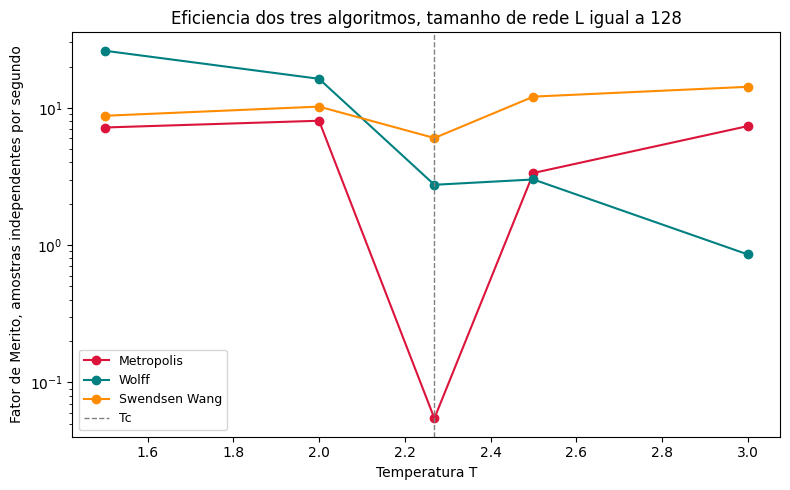

In [7]:

L_para_grafico = max(L_valores)
cores_algoritmo = {'metropolis': 'crimson', 'wolff': 'teal', 'swendsen_wang': 'darkorange'}
nomes_exibicao = {'metropolis': 'Metropolis', 'wolff': 'Wolff', 'swendsen_wang': 'Swendsen Wang'}
Tc = temperatura_critica_onsager()

fig, ax = plt.subplots(figsize=(8, 5))

for algoritmo in algoritmos:
    Ts_disponiveis = sorted(T for (a, L, T) in resultados_desempenho if a == algoritmo and L == L_para_grafico)
    etas = [resultados_desempenho[(algoritmo, L_para_grafico, T)]['eta_e'] for T in Ts_disponiveis]
    ax.plot(Ts_disponiveis, etas, 'o-', color=cores_algoritmo[algoritmo], label=nomes_exibicao[algoritmo])

ax.axvline(Tc, ls='--', color='gray', lw=1, label='Tc')
ax.set_yscale('log')
ax.set_xlabel('Temperatura T')
ax.set_ylabel('Fator de Merito, amostras independentes por segundo')
ax.set_title(f'Eficiencia dos tres algoritmos, tamanho de rede L igual a {L_para_grafico}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{PASTA_DADOS}/fator_merito_L{L_para_grafico}.png', dpi=150)
plt.show()



## Como a eficiência muda com o tamanho da rede, perto de Tc

Este segundo gráfico fixa a temperatura mais próxima de Tc e mostra como
o Fator de Mérito de cada algoritmo se comporta conforme a rede cresce.
Essa é a comparação mais direta com os expoentes críticos dinâmicos
discutidos no Capítulo 3: um algoritmo com expoente z maior deve perder
eficiência mais rápido conforme L aumenta.


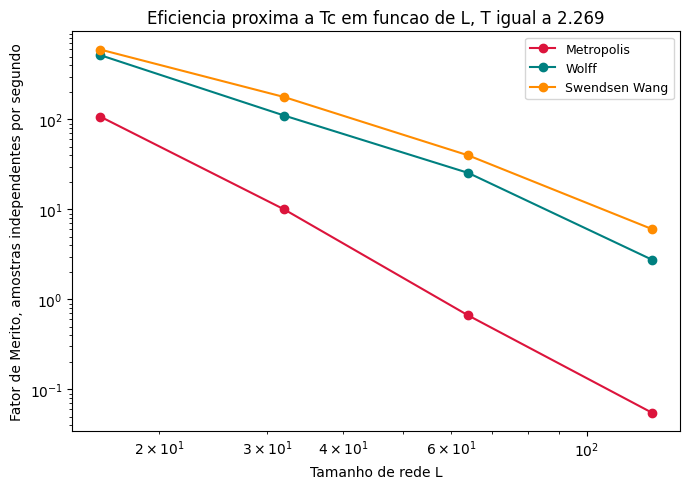

In [8]:

T_critica_usada = min(T_valores, key=lambda T: abs(T - Tc))

fig, ax = plt.subplots(figsize=(7, 5))

for algoritmo in algoritmos:
    Ls_disponiveis = sorted(L for (a, L, T) in resultados_desempenho if a == algoritmo and T == T_critica_usada)
    etas = [resultados_desempenho[(algoritmo, L, T_critica_usada)]['eta_e'] for L in Ls_disponiveis]
    ax.plot(Ls_disponiveis, etas, 'o-', color=cores_algoritmo[algoritmo], label=nomes_exibicao[algoritmo])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Tamanho de rede L')
ax.set_ylabel('Fator de Merito, amostras independentes por segundo')
ax.set_title(f'Eficiencia proxima a Tc em funcao de L, T igual a {T_critica_usada}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{PASTA_DADOS}/fator_merito_vs_L.png', dpi=150)
plt.show()



## Salvando o resumo de desempenho

Assim como no notebook de autocorrelação, salvamos um arquivo compacto
com os resultados, para uso posterior.


In [9]:

resumo_desempenho_serializavel = {
    f"{algoritmo}|{L}|{T}": {k: float(v) for k, v in dados.items()}
    for (algoritmo, L, T), dados in resultados_desempenho.items()
}

caminho_resumo = f'{PASTA_DADOS}/resumo_desempenho.json'
with open(caminho_resumo, 'w') as arquivo:
    json.dump(resumo_desempenho_serializavel, arquivo, indent=2)

print(f"Resumo salvo em, {caminho_resumo}")
print(f"Total de combinacoes no resumo, {len(resumo_desempenho_serializavel)}")


Resumo salvo em, /content/drive/MyDrive/0_TCC_Diego/dados/resumo_desempenho.json
Total de combinacoes no resumo, 60
